Saved fig1A_meter_windows.png


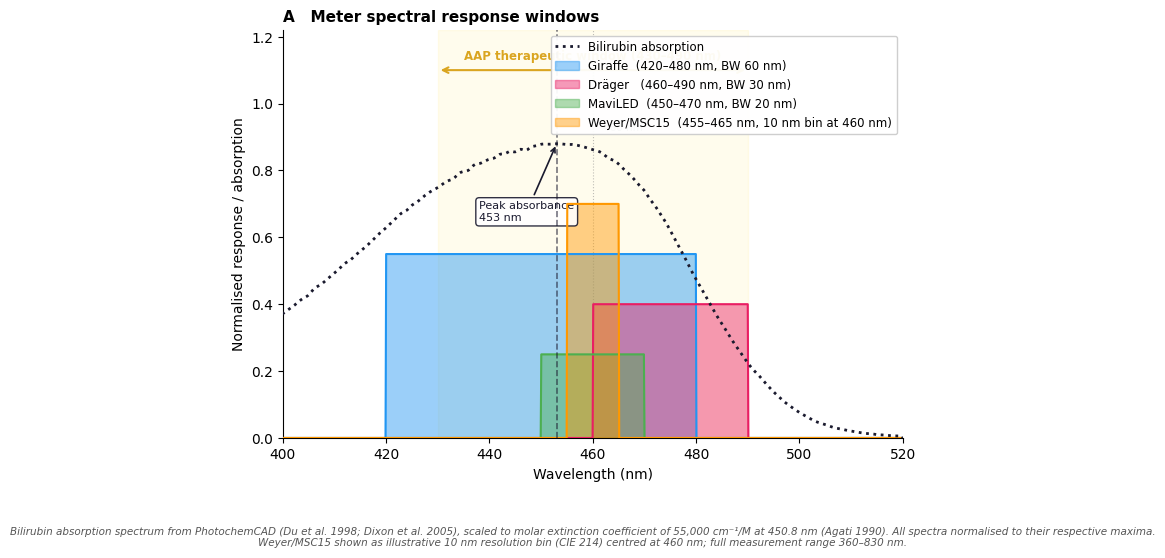

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ── Real bilirubin absorption data (PhotochemCAD) ─────────────────────────────
bili_raw = {
    380: 11551, 381: 12026, 382: 12376, 383: 12831, 384: 13339,
    385: 13778, 386: 14245, 387: 14794, 388: 15217, 389: 15763,
    390: 16334, 391: 16897, 392: 17508, 393: 18306, 394: 18947,
    395: 19603, 396: 20306, 397: 21025, 398: 21695, 399: 22456,
    400: 23223, 401: 23938, 402: 24617, 403: 25435, 404: 26126,
    405: 26737, 406: 27857, 407: 28467, 408: 29168, 409: 30049,
    410: 30831, 411: 31698, 412: 32610, 413: 33200, 414: 34095,
    415: 34903, 416: 35706, 417: 36596, 418: 37558, 419: 38475,
    420: 39293, 421: 40236, 422: 41146, 423: 42024, 424: 42569,
    425: 43491, 426: 44106, 427: 44920, 428: 45653, 429: 46284,
    430: 46801, 431: 47497, 432: 48068, 433: 48455, 434: 49361,
    435: 49796, 436: 50080, 437: 50999, 438: 51272, 439: 51653,
    440: 52109, 441: 52356, 442: 53001, 443: 53133, 444: 53570,
    445: 53466, 446: 53945, 447: 53727, 448: 54336, 449: 54593,
    450: 54889, 451: 54904, 452: 54913, 453: 54985, 454: 54944,
    455: 54838, 456: 54852, 457: 54697, 458: 54456, 459: 54179,
    460: 53869, 461: 53612, 462: 53073, 463: 52297, 464: 51893,
    465: 51182, 466: 50213, 467: 49358, 468: 48330, 469: 47213,
    470: 46188, 471: 44709, 472: 43437, 473: 41989, 474: 40495,
    475: 38765, 476: 36981, 477: 35156, 478: 33338, 479: 31378,
    480: 29636, 481: 27950, 482: 26271, 483: 24544, 484: 22833,
    485: 21333, 486: 19771, 487: 18211, 488: 16794, 489: 15367,
    490: 14025, 491: 12797, 492: 11835, 493: 10718, 494:  9634,
    495:  8611, 496:  7707, 497:  6821, 498:  6090, 499:  5400,
    500:  4767, 501:  4204, 502:  3654, 503:  3151, 504:  2794,
    505:  2503, 506:  2144, 507:  1863, 508:  1702, 509:  1466,
    510:  1299, 511:  1116, 512:   966, 513:   846, 514:   782,
    515:   624, 516:   582, 517:   485, 518:   396, 519:   401,
    520:   340,
}

bili_wl  = np.array(sorted(bili_raw.keys()), dtype=float)
bili_ext = np.array([bili_raw[w] for w in sorted(bili_raw.keys())], dtype=float)
f_bili   = interp1d(bili_wl, bili_ext, kind='cubic', bounds_error=False, fill_value=0)
wl       = np.linspace(370, 615, 2000)
bili     = f_bili(wl)
bili     = np.clip(bili, 0, None)
bili    /= bili.max()

bili_peak_wl = 453.0

# ── Helpers ───────────────────────────────────────────────────────────────────
def flat_band(wl, lo, hi, amp=1.0, edge=3):
    y = np.zeros_like(wl, dtype=float)
    y[(wl >= lo) & (wl <= hi)] = amp
    y[(wl >= lo - edge) & (wl < lo)] = amp * (wl[(wl >= lo - edge) & (wl < lo)] - (lo - edge)) / edge
    y[(wl > hi) & (wl <= hi + edge)] = amp * ((hi + edge) - wl[(wl > hi) & (wl <= hi + edge)]) / edge
    return y

def meter_window(wl, lo, hi):
    w = np.zeros_like(wl)
    w[(wl >= lo) & (wl <= hi)] = 1.0
    return w

# ── Meter windows ─────────────────────────────────────────────────────────────
giraffe_w = meter_window(wl, 420, 480)
drager_w  = meter_window(wl, 460, 490)
maviled_w = meter_window(wl, 450, 470)
weyer_w   = meter_window(wl, 455, 465)

# ── Colours ───────────────────────────────────────────────────────────────────
C_BILI    = '#1a1a2e'
C_GIRAFFE = '#2196F3'
C_DRAGER  = '#E91E63'
C_MAVI    = '#4CAF50'
C_WEYER   = '#FF9800'
AAP_LO, AAP_HI = 430, 490

CAPTION = (
    'Bilirubin absorption spectrum from PhotochemCAD (Du et al. 1998; Dixon et al. 2005), '
    'scaled to molar extinction coefficient of 55,000 cm\u207b\u00b9/M at 450.8 nm (Agati 1990). '
    'All spectra normalised to their respective maxima.\n'
    'Weyer/MSC15 shown as illustrative 10 nm resolution bin (CIE 214) centred at 460 nm; '
    'full measurement range 360\u2013830 nm.'
)

# ── Figure A ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
fig.subplots_adjust(bottom=0.20)

ax.set_title('A   Meter spectral response windows',
             loc='left', fontsize=11, fontweight='bold', pad=6)
ax.set_xlabel('Wavelength (nm)', fontsize=10)
ax.set_ylabel('Normalised response / absorption', fontsize=10)
ax.set_xlim(400, 520)
ax.set_ylim(0, 1.22)
ax.spines[['top', 'right']].set_visible(False)

ax.axvspan(AAP_LO, AAP_HI, alpha=0.07, color='gold', zorder=0)
ax.axvline(460, color='gray', lw=0.8, ls=':', alpha=0.5, zorder=1)
ax.text(462, 0.92, '460 nm', fontsize=7.5, color='gray')

# AAP annotation on top
ax.annotate('', xy=(AAP_HI, 1.10), xytext=(AAP_LO, 1.10),
            arrowprops=dict(arrowstyle='<->', color='goldenrod', lw=1.5))
ax.text((AAP_LO + AAP_HI) / 2, 1.13,
        'AAP therapeutic window (430\u2013490 nm)',
        ha='center', fontsize=8.5, color='goldenrod', fontweight='bold')

# Bilirubin dotted
ax.plot(wl, bili * 0.88, color=C_BILI, lw=2.0, ls=':',
        label='Bilirubin absorption', zorder=5)

# Peak absorbance marker
ax.axvline(bili_peak_wl, color=C_BILI, lw=1.2, ls='--', alpha=0.6, zorder=4)
ax.annotate(f'Peak absorbance\n{bili_peak_wl:.0f} nm',
            xy=(float(bili_peak_wl), 0.88),
            xytext=(bili_peak_wl - 15, 0.65),
            fontsize=8, color=C_BILI,
            arrowprops=dict(arrowstyle='->', color=C_BILI, lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=C_BILI, alpha=0.9))

# Meter windows
meter_specs = [
    ('Giraffe  (420\u2013480 nm, BW 60 nm)',                 giraffe_w * 0.55, C_GIRAFFE),
    ('Dr\u00e4ger   (460\u2013490 nm, BW 30 nm)',            drager_w  * 0.40, C_DRAGER),
    ('MaviLED  (450\u2013470 nm, BW 20 nm)',                 maviled_w * 0.25, C_MAVI),
    ('Weyer/MSC15  (455\u2013465 nm, 10 nm bin at 460 nm)',  weyer_w   * 0.70, C_WEYER),
]
for label, h, c in meter_specs:
    ax.fill_between(wl, h, alpha=0.45, color=c, label=label, zorder=2)
    ax.plot(wl, h, color=c, lw=1.5, zorder=3)

ax.legend(loc='upper right', fontsize=8.5, framealpha=0.95, edgecolor='#cccccc')

fig.text(0.5, 0.02, CAPTION, ha='center', fontsize=7.5, color='#555555', style='italic')

fig.savefig('fig1A_meter_windows.png', dpi=180, bbox_inches='tight', facecolor='white')
print("Saved fig1A_meter_windows.png")
plt.show()
plt.close(fig)